In [1]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [2]:
PROJ_PATH = Path(os.getcwd()).parent
DATA_PATH = PROJ_PATH / 'Data'

In [3]:
# Read in data and move target column to the end
march_madness = pd.read_csv(DATA_PATH / 'march_madness_historical_data.csv')
target_col = march_madness.pop('UPSET')
march_madness.insert(march_madness.shape[1], 'UPSET', target_col)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(march_madness.iloc[:, :-1], march_madness['UPSET'], random_state=1,
                                                    stratify=march_madness['UPSET'])

In [5]:
print(f"Percentage of samples that were an upset: {round(np.mean(march_madness['UPSET'])*100, 2)}%")
print(f"Percentage of samples in training set that were an upset: {round(np.mean(y_train)*100, 2)}%")
print(f"Percentage of samples in test set that were an upset: {round(np.mean(y_test)*100, 2)}%")

Percentage of samples that were an upset: 29.85%
Percentage of samples in training set that were an upset: 29.91%
Percentage of samples in test set that were an upset: 29.68%


In [6]:
X_train = X_train.drop(columns=['YEAR', 'BETTER_TEAM', 'WORSE_TEAM'])
X_test = X_test.drop(columns=['YEAR', 'BETTER_TEAM', 'WORSE_TEAM'])

# Exploratory Data Analysis

In [7]:
X_train

,ROUND,BETTER_SEED,WORSE_SEED,KENPOM ADJUSTED EFFICIENCY,KENPOM ADJUSTED OFFENSE,KENPOM ADJUSTED DEFENSE,KENPOM ADJUSTED TEMPO,BARTTORVIK ADJUSTED EFFICIENCY,BARTTORVIK ADJUSTED OFFENSE,BARTTORVIK ADJUSTED DEFENSE,...,3PT RATE DEFENSE,OP ASSIST %,OP O REB %,OP D REB %,BLOCKED %,TURNOVER % DEFENSE,WINS ABOVE BUBBLE,WIN %,POINTS PER POSSESSION OFFENSE,POINTS PER POSSESSION DEFENSE
7,3,1,4,NaN,NaN,-12.5377,NaN,11.761,NaN,NaN,...,0.4,-3.0,NaN,NaN,-2.2,3.9,NaN,21.568620,NaN,NaN
65,0,11,11,NaN,NaN,-5.8024,NaN,-4.470,NaN,NaN,...,9.4,2.6,NaN,NaN,-1.8,4.5,NaN,6.108380,NaN,NaN
895,2,4,5,7.8,-1.0,-8.9000,0.3,6.000,-2.1,-8.1,...,-2.9,-12.0,1.3,-4.9,-2.6,0.3,0.7,0.000000,-0.029,-0.094
392,1,3,14,20.1,3.5,-16.8000,-1.4,19.000,3.7,-15.3,...,0.5,-2.5,2.1,2.1,-4.4,4.5,9.0,6.250000,-0.016,-0.050
32,1,2,15,NaN,NaN,-15.0570,NaN,24.584,NaN,NaN,...,5.4,10.5,NaN,NaN,2.1,0.0,NaN,16.193180,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,4,2,5,4.9,4.7,-0.2000,6.3,7.200,6.5,-0.7,...,-1.9,2.5,6.1,-9.8,-1.3,2.5,2.3,-9.370000,0.017,0.031
133,0,16,16,NaN,NaN,7.8740,NaN,1.607,NaN,NaN,...,-8.0,-12.3,NaN,NaN,1.2,-0.3,NaN,1.724138,NaN,NaN
996,1,4,13,13.4,5.8,-7.6000,-2.8,12.200,4.7,-7.5,...,2.1,-2.0,-1.2,-4.5,-0.3,-1.9,9.7,18.780000,0.022,-0.085
516,1,7,10,10.3,8.9,-1.4000,-8.9,11.900,10.3,-1.6,...,-3.1,-4.3,-6.1,-2.0,-1.6,-5.6,2.6,11.030000,0.115,-0.022


In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 846 entries, 7 to 388
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ROUND                           846 non-null    int64  
 1   BETTER_SEED                     846 non-null    int64  
 2   WORSE_SEED                      846 non-null    int64  
 3   KENPOM ADJUSTED EFFICIENCY      747 non-null    float64
 4   KENPOM ADJUSTED OFFENSE         747 non-null    float64
 5   KENPOM ADJUSTED DEFENSE         846 non-null    float64
 6   KENPOM ADJUSTED TEMPO           747 non-null    float64
 7   BARTTORVIK ADJUSTED EFFICIENCY  846 non-null    float64
 8   BARTTORVIK ADJUSTED OFFENSE     747 non-null    float64
 9   BARTTORVIK ADJUSTED DEFENSE     747 non-null    float64
 10  BARTHAG                         747 non-null    float64
 11  ELITE SOS                       846 non-null    float64
 12  BARTTORVIK ADJUSTED TEMPO       846 non-n

## Note
The following EDA was performed on the 2008-2023 data and was helpful in choosing which features to include. Beginning with 2024 data, only these relevant features were collected, so the following analysis is not relevant to the dataset including matchups beyond 2024.

TLDR; Don't run the following cells with data beyond 2024 as it will not be relevant and the output of the below cells is important for historical purposes.

In [9]:
X_train.describe()

,ROUND,BETTER_SEED,WORSE_SEED,KENPOM ADJUSTED EFFICIENCY,KENPOM ADJUSTED OFFENSE,KENPOM ADJUSTED DEFENSE,KENPOM ADJUSTED TEMPO,BARTTORVIK ADJUSTED EFFICIENCY,BARTTORVIK ADJUSTED OFFENSE,BARTTORVIK ADJUSTED DEFENSE,...,3PT RATE DEFENSE,OP ASSIST %,OP O REB %,OP D REB %,BLOCKED %,TURNOVER % DEFENSE,WINS ABOVE BUBBLE,WIN %,POINTS PER POSSESSION OFFENSE,POINTS PER POSSESSION DEFENSE
count,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,...,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000
mean,1.788204,4.100536,10.335121,9.508862,5.057634,-4.457517,0.189803,9.534035,5.360016,-4.174019,...,-0.189812,-0.585925,-0.175737,-1.523592,-0.267694,0.082306,5.346649,8.284354,0.031865,-0.024408
std,1.234045,3.330046,3.826124,9.162092,6.753289,6.272741,4.088511,9.411373,7.184228,5.972536,...,5.299915,7.188249,4.023590,5.495312,2.122330,3.457036,4.719583,12.431042,0.063507,0.060214
min,0.000000,1.000000,1.000000,-10.700000,-15.400000,-24.400000,-11.900000,-10.400000,-16.800000,-24.314000,...,-15.400000,-23.100000,-12.200000,-17.600000,-7.300000,-11.100000,-3.100000,-23.100000,-0.153000,-0.253000
25%,1.000000,2.000000,8.000000,2.900000,0.300000,-8.300000,-2.400000,2.900000,0.225000,-7.900000,...,-4.000000,-5.350000,-2.800000,-5.175000,-1.600000,-2.200000,2.000000,0.000000,-0.009750,-0.062000
50%,1.000000,3.000000,11.000000,7.800000,4.700000,-3.900000,0.200000,7.822000,5.000000,-3.407500,...,-0.200000,-0.950000,-0.200000,-1.600000,-0.300000,0.150000,4.500000,8.115000,0.028000,-0.023000
75%,2.000000,6.000000,13.000000,13.975000,9.200000,-0.300000,2.900000,14.194000,9.900000,-0.200000,...,3.575000,4.175000,2.500000,2.100000,1.100000,2.400000,7.475000,15.942500,0.076000,0.014000
max,6.000000,16.000000,16.000000,45.600000,26.600000,12.495400,14.100000,44.800000,27.000000,13.284000,...,16.000000,23.300000,12.500000,14.300000,7.000000,10.700000,22.900000,48.670000,0.214000,0.158000


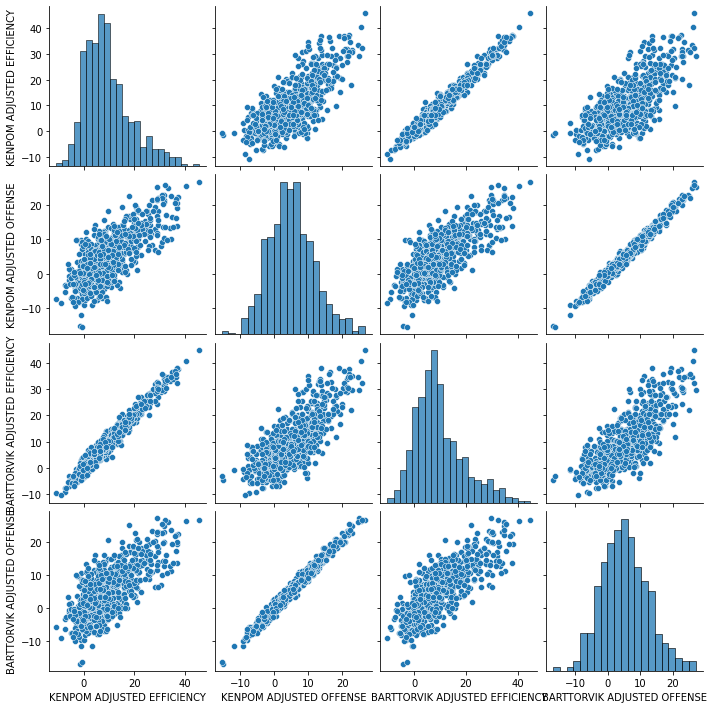

In [10]:
sns.pairplot(data=X_train[['KENPOM ADJUSTED EFFICIENCY', 'KENPOM ADJUSTED OFFENSE', 'BARTTORVIK ADJUSTED EFFICIENCY', 'BARTTORVIK ADJUSTED OFFENSE']])

### Notes
As suspected, there is heavy correlation between some predictor variables. **Feature selection should be performed**

<BarContainer object of 39 artists>

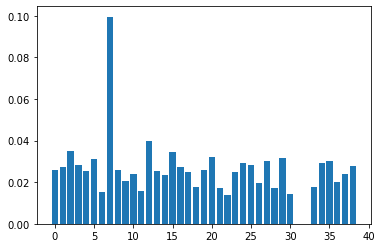

In [11]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

plt.bar(range(len(xgb.feature_importances_)), xgb.feature_importances_)

In [12]:
[xgb.feature_names_in_[i] for i in np.argsort(xgb.feature_importances_)[::-1]]

['BARTTORVIK ADJUSTED EFFICIENCY',
 'BARTTORVIK ADJUSTED TEMPO',
 'WORSE_SEED',
 'FREE THROW %',
 'OFFENSIVE REBOUND %',
 '3PT RATE DEFENSE',
 'KENPOM ADJUSTED DEFENSE',
 'WINS ABOVE BUBBLE',
 'EFG % DEFENSE',
 '2PT % DEFENSE',
 'TURNOVER % DEFENSE',
 'KENPOM ADJUSTED EFFICIENCY',
 '3PT % DEFENSE',
 'POINTS PER POSSESSION DEFENSE',
 'BETTER_SEED',
 'EFG %',
 'ROUND',
 'BARTTORVIK ADJUSTED OFFENSE',
 'ASSIST %',
 '2PT %',
 'KENPOM ADJUSTED OFFENSE',
 'FREE THROW RATE',
 'TURNOVER %',
 'POINTS PER POSSESSION OFFENSE',
 'BARTHAG',
 '3PT %',
 'BARTTORVIK ADJUSTED DEFENSE',
 'WIN %',
 'FREE THROW % DEFENSE',
 'BLOCKED %',
 '3PT RATE',
 'FREE THROW RATE DEFENSE',
 'DEFENSIVE REBOUND %',
 'ELITE SOS',
 'KENPOM ADJUSTED TEMPO',
 'OP ASSIST %',
 'BLOCK %',
 'OP O REB %',
 'OP D REB %']

In [13]:
def find_important_uncorrelated_features(data, important_sorted_feature_names):
    final_feature_set = []
    for new_feature in important_sorted_feature_names:
        if len(final_feature_set) == 0:
            final_feature_set.append(new_feature)
        else:
            correlation_coefficients = [abs(np.corrcoef(data[selected_feature], data[new_feature])[0][1]) for selected_feature in final_feature_set]
            
            print(f"New Feature: {new_feature}, Max R: {max(correlation_coefficients)}")
            if max(correlation_coefficients) < 0.7:
                final_feature_set.append(new_feature)
    
    return final_feature_set

In [14]:
selected_features = find_important_uncorrelated_features(X_train, [xgb.feature_names_in_[i] for i in np.argsort(xgb.feature_importances_)[::-1]])
selected_features

New Feature: BARTTORVIK ADJUSTED TEMPO, Max R: 0.05040577189620303
New Feature: WORSE_SEED, Max R: 0.5488835024419831
New Feature: FREE THROW %, Max R: 0.06636133044684449
New Feature: OFFENSIVE REBOUND %, Max R: 0.31721780939932864
New Feature: 3PT RATE DEFENSE, Max R: 0.11409700285933234
New Feature: KENPOM ADJUSTED DEFENSE, Max R: 0.6141892926842552
New Feature: WINS ABOVE BUBBLE, Max R: 0.8720952242969866
New Feature: EFG % DEFENSE, Max R: 0.6943647342513822
New Feature: 2PT % DEFENSE, Max R: 0.8760824974301058
New Feature: TURNOVER % DEFENSE, Max R: 0.30012165126694895
New Feature: KENPOM ADJUSTED EFFICIENCY, Max R: 0.9795293004347183
New Feature: 3PT % DEFENSE, Max R: 0.5860261358365348
New Feature: POINTS PER POSSESSION DEFENSE, Max R: 0.80907678128876
New Feature: BETTER_SEED, Max R: 0.4578987974902415
New Feature: EFG %, Max R: 0.32356829054773195
New Feature: ROUND, Max R: 0.6857095118383403
New Feature: BARTTORVIK ADJUSTED OFFENSE, Max R: 0.7728927495507432
New Feature: ASSI

['BARTTORVIK ADJUSTED EFFICIENCY',
 'BARTTORVIK ADJUSTED TEMPO',
 'WORSE_SEED',
 'FREE THROW %',
 'OFFENSIVE REBOUND %',
 '3PT RATE DEFENSE',
 'KENPOM ADJUSTED DEFENSE',
 'EFG % DEFENSE',
 'TURNOVER % DEFENSE',
 '3PT % DEFENSE',
 'BETTER_SEED',
 'EFG %',
 'ROUND',
 'ASSIST %',
 'FREE THROW RATE',
 'TURNOVER %',
 'WIN %',
 'FREE THROW % DEFENSE',
 'BLOCKED %',
 '3PT RATE',
 'FREE THROW RATE DEFENSE',
 'DEFENSIVE REBOUND %',
 'ELITE SOS',
 'OP ASSIST %',
 'BLOCK %']

In [15]:
len(selected_features)

25

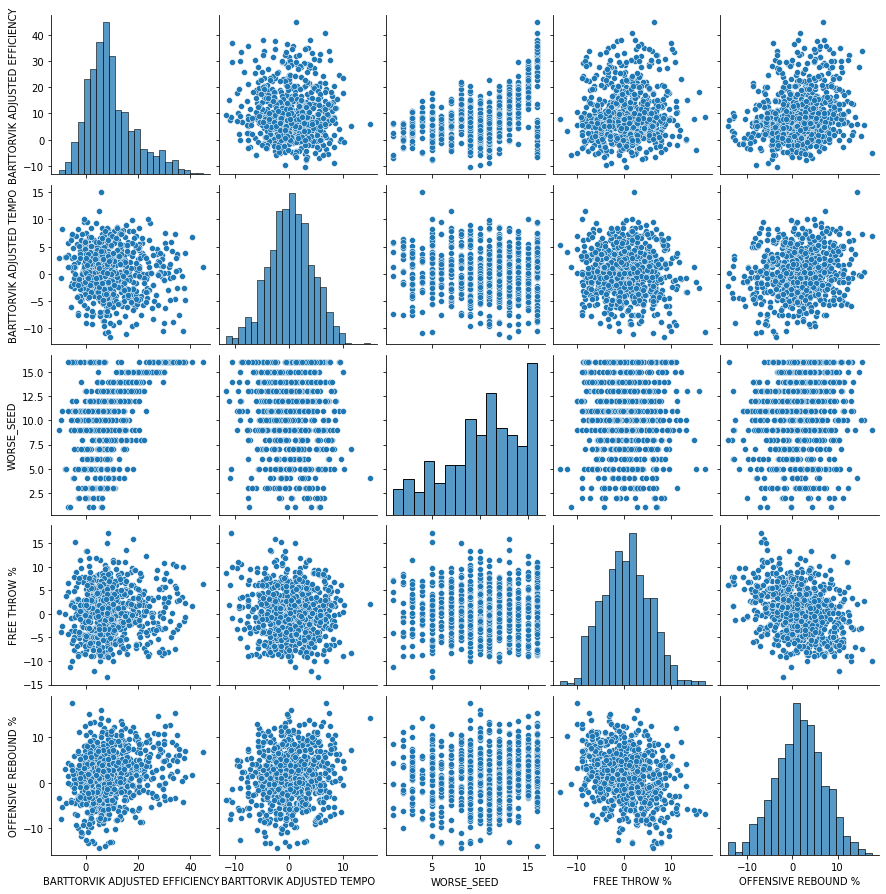

In [16]:
sns.pairplot(X_train.iloc[:, np.argsort(xgb.feature_importances_)[:-6:-1]])

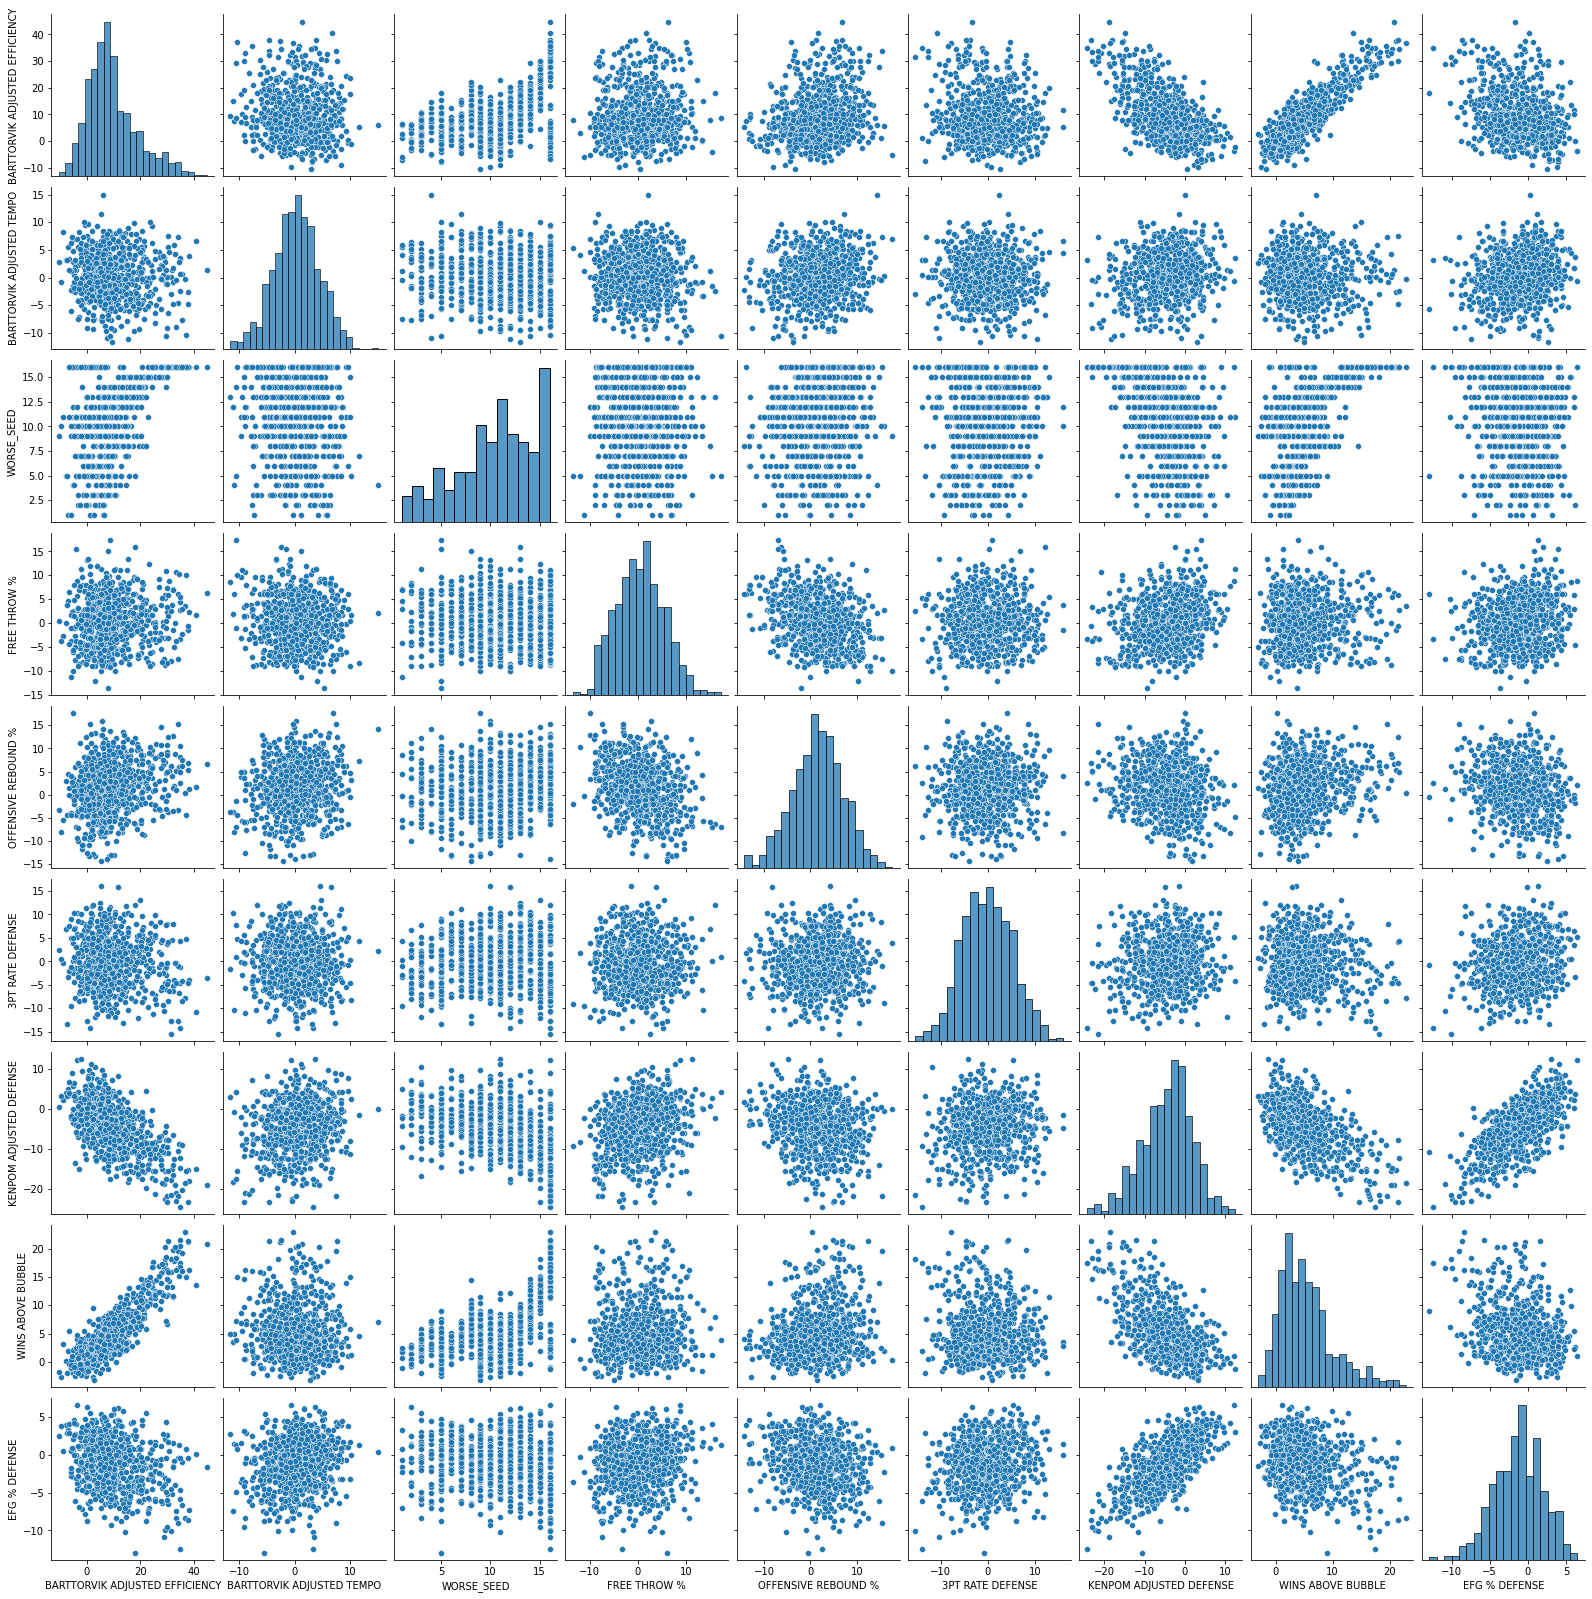

In [17]:
sns.pairplot(X_train.iloc[:, np.argsort(xgb.feature_importances_)[:-10:-1]])

## Note
Run the below cell to replace the final output `selected_features` when using data beyond 2024

In [9]:
selected_features = [
    'BARTTORVIK ADJUSTED EFFICIENCY',
    'BARTTORVIK ADJUSTED TEMPO',
    'WORSE_SEED',
    'FREE THROW %',
    'OFFENSIVE REBOUND %',
    '3PT RATE DEFENSE',
    'KENPOM ADJUSTED DEFENSE',
    'EFG % DEFENSE',
    'TURNOVER % DEFENSE',
    '3PT % DEFENSE',
    'BETTER_SEED',
    'EFG %',
    'ROUND',
    'ASSIST %',
    'FREE THROW RATE',
    'TURNOVER %',
    'WIN %',
    'FREE THROW % DEFENSE',
    'BLOCKED %',
    '3PT RATE',
    'FREE THROW RATE DEFENSE',
    'DEFENSIVE REBOUND %',
    'ELITE SOS',
    'OP ASSIST %',
    'BLOCK %'
]

In [10]:
selected_features.remove('ROUND')
selected_features.remove('BETTER_SEED')
selected_features.remove('WORSE_SEED')

In [11]:
train = X_train.copy().loc[:, ['ROUND', 'BETTER_SEED', 'WORSE_SEED'] + selected_features]
train['UPSET'] = y_train.copy()
train.to_csv(DATA_PATH / 'train.csv', index=False)

test = X_test.copy().loc[:, ['ROUND', 'BETTER_SEED', 'WORSE_SEED'] + selected_features]
test['UPSET'] = y_test.copy()
test.to_csv(DATA_PATH / 'test.csv', index=False)

full_dataset = march_madness.copy().loc[:, ['ROUND', 'BETTER_SEED', 'WORSE_SEED'] + selected_features]
full_dataset['UPSET'] = march_madness['UPSET'].copy()
full_dataset.to_csv(DATA_PATH / 'full_dataset.csv', index=False)